# Deep Reconstruction of SIRS Model in Julia

This notebook is a Julia implementation of the Python notebook for modeling deep dynamic systems. It covers the following three architectures:
1.  **ResNet**
2.  **Neural Ordinary Differential Equation (Neural ODE)**
3.  **Universal Differential Equation (UDE)**

In [1]:
using DifferentialEquations, DiffEqFlux, Flux, Functors, Optimisers, Plots, BSON, Printf
# Plotly backend
plotly()

Plots.PlotlyBackend()

## 1. Ground Truth Data 

In [2]:
function sirs_deriv!(du, u, p, t)
    S, I, R = u
    β, γ, θ, μ = p
    du[1] = -β * S * I + θ * R - μ * S
    du[2] =  β * S * I - γ * I - μ * I
    du[3] =  γ * I - θ * R - μ * R
end

sirs_deriv! (generic function with 1 method)

In [4]:
# True parameters for the ground truth model
γ = 1/7
μ = 1/(80*365)
θ = 1/365
β = 2*(μ + γ)

p_true = Float32[β, γ, θ, μ]
u0      = Float32[0.999, 0.001, 0.0]
tspan   = (0.0f0, 2000.0f0)
tsteps  = 0.0f0:1.0f0:2000.0f0

# Define true solution
prob_true     = ODEProblem(sirs_deriv!, u0, tspan, p_true)
sol_true      = solve(prob_true, Tsit5(), saveat = tsteps)
true_traj     = Array(sol_true)

3×2001 Matrix{Float32}:
 0.999  0.998659     0.998272    …  0.499346    0.499385    0.499425
 0.001  0.00115322   0.00132978     0.00779363  0.00779222  0.0077909
 0.0    0.000153335  0.00032973     0.426724    0.426654    0.426583

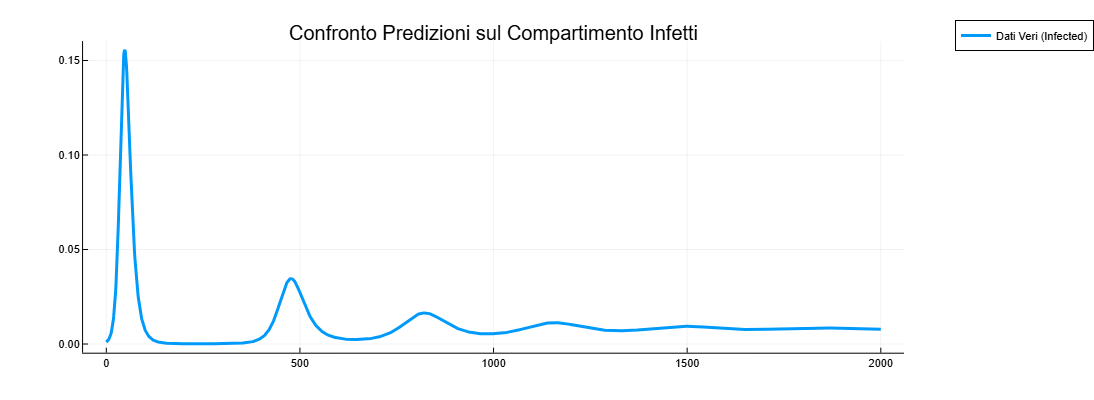

In [5]:
# plot the data
plot(
    tsteps,
    true_traj[2, :], 
    lw=3,
    ls=:solid,
    label="Dati Veri (Infected)",
    title="Confronto Predizioni sul Compartimento Infetti",
    xlabel="Tempo (giorni)",
    ylabel="Frazione di Infetti",
    legend=:outertopright,
)

In [7]:
# calculate second true_traj
β_2 = 10*(μ + γ)

tspan_2   = (0.0f0, 500.0f0)
tsteps_2  = 0.0f0:1.0f0:500.0f0

# Define true solution
prob_true_2     = ODEProblem(sirs_deriv!, u0, tspan_2, p_true)
sol_true_2      = solve(prob_true, Tsit5(), saveat = tsteps_2)
true_traj_2     = Array(sol_true)

3×2001 Matrix{Float32}:
 0.999  0.998659     0.998272    …  0.499346    0.499385    0.499425
 0.001  0.00115322   0.00132978     0.00779363  0.00779222  0.0077909
 0.0    0.000153335  0.00032973     0.426724    0.426654    0.426583

In [10]:
# plot side by side
fig_1 = plot(
    tsteps,
    true_traj[2, :], 
    lw=3,
    ls=:solid,
    label="Dati Veri (Infected)",
    title="Confronto Predizioni sul Compartimento Infetti",
    xlabel="Tempo (giorni)",
    ylabel="Frazione di Infetti",
    legend=:outertopright,
)

fig_2 = plot(
    tsteps_2,
    true_traj_2[2, :], 
    lw=3,
    ls=:solid,
    label="Dati Veri (Infected)",
    title="Confronto Predizioni sul Compartimento Infetti",
    xlabel="Tempo (giorni)",
    ylabel="Frazione di Infetti",
    legend=:outertopright,
)

plot(fig_1, fig_2, layout = (1, 2), size = (1000, 500), title = "Confronto tra due traiettorie SIRS", xlabel = "Tempo (giorni)", ylabel = "Frazione di Infetti")

## 2. ResNet

In [12]:
# ResNet block
resblock = Flux.Chain(
    Flux.Dense(3, 64, relu),
    Flux.Dense(64, 64, relu),
    Flux.Dense(64, 3)
)

# Define the skip connection
resnet_model(x, m) = x .+ m(x)

# COnverting data to Float32 type so they are easier to train
X = Float32.(true_traj[:, 1:end-1])
Y = Float32.(true_traj[:, 2:end])

opt = ADAM(1e-3)

state = Flux.setup(opt, resblock)

# Loss function (just MSE between predicted and ground truth values)
function loss(m, x, y)
    ŷ = resnet_model(x, m)
    return Flux.Losses.mse(ŷ, y)
end

loss (generic function with 1 method)

In [13]:
# Training loop for ResNet
println("Training ResNet discreto…")
for epoch in 1:10000
    gs = gradient(resblock) do m
        loss(m, X, Y)
    end
    Flux.update!(state, resblock, gs[1])

    if epoch % 100 == 0
        @printf("  epoch %d, loss = %.8f\n", epoch, loss(resblock, X, Y))
    end
end


Training ResNet discreto…
  epoch 100, loss = 0.00000231
  epoch 200, loss = 0.00000073


LoadError: InterruptException:

In [14]:
# --- Save ResNet Model ---
# filepath = "deep_models_julia/2 resnet LOSS $(round(loss(resblock, X, Y), digits=5)) EPOCH 1000.bson"
# BSON.bson(filepath, Dict("model" => resblock))
# println("ResNet model saved to $(filepath) ")

filepath = "deep_models_julia/resnet LOSS 0.0 EPOCH 1000.bson"
loaded_data = BSON.load(filepath)
resblock = loaded_data["model"]

Chain(
  Dense(3 => 64, relu),                 # 256 parameters
  Dense(64 => 64, relu),                # 4_160 parameters
  Dense(64 => 3),                       # 195 parameters
)                   # Total: 6 arrays, 4_611 parameters, 18.316 KiB.

## 3. Neural Ordinary Differential Equations (Neural ODE)

In [48]:
# Define the NeuralODE model
neural_ode_func = Flux.Chain(
  Flux.Dense(3, 64, tanh),
  Flux.Dense(64, 64, tanh),
  Flux.Dense(64, 3)
)

p, st = Flux.destructure(neural_ode_func)

opt = Optimisers.Adam(1e-3)
state = Optimisers.setup(opt, p)

# The method helps to reconstruct the ODE system from the neural network
function reconstruct_sirs(du, u, p, t)
    curr_deriv = st(p)(u)
    du[1] = curr_deriv[1]
    du[2] = curr_deriv[2]
end

# Method to predict the trajectory using the neural ODE
function predict_neural_ode(p)
    return Array(solve(n_ode, 
            Tsit5(), 
            p=p, 
            saveat=tsteps, 
            sensealg=InterpolatingAdjoint(
                autojacvec=ReverseDiffVJP(true)
                )
            ))
end

function loss_neural(p)
    pred_sol = predict_neural_ode(p)
    loss = sum(abs2, Array(pred_sol) .- true_traj)
    return loss
end

# Define the ODE problem
n_ode = ODEProblem(
    reconstruct_sirs,
    u0,
    tspan,
    p  
)

ODEProblem with uType Vector{Float32} and tType Float32. In-place: true
Non-trivial mass matrix: false
timespan: (0.0f0, 2000.0f0)
u0: 3-element Vector{Float32}:
 0.999
 0.001
 0.0

In [ ]:
# Training loop for the Neural ODE
println("Training Neural ODE…")
opt = Optimisers.Adam(1e-3)

for epoch in 1:1000
    grads = gradient(loss_neural, p)[1]

    # Update the parameters using the optimizer
    state, p = Optimisers.update(state, p, grads)
    
    if epoch % 20 == 0
        current_loss = loss_neural(p)
        println("Epoch $epoch | Loss = ", current_loss)
    end
end

In [49]:
# --- Save Neural ODE Parameters ---
# filepath = "deep_models_julia/node LOSS $(round(loss_neural(p), digits=4)) EPOCH 1000.bson"
# BSON.bson(filepath, Dict("params" => p))

# println("Neural ODE parameters saved to $(filepath)")

filepath = "deep_models_julia/node LOSS 379.9356 EPOCH 1000.bson"
loaded_data = BSON.load(filepath)
p = loaded_data["params"]
# 
# pred = solve(n_ode, Tsit5(), p=loaded_p_neural, saveat=tsteps)

4611-element Vector{Float32}:
  0.03652007
 -0.19501272
 -0.053761493
  0.115986876
  0.11234556
  0.029771259
  0.043585476
 -0.061829403
  0.11519431
  0.064183064
 -0.18690711
 -0.2682172
 -0.04138193
  ⋮
  0.1124093
 -0.044178545
  0.22094387
  0.1555491
 -0.17685342
  0.15258008
 -0.114772715
  0.064926654
 -0.16213153
 -0.005610938
  0.0058055166
  0.0

## 4. Universal Differential Equations (UDE)

In [50]:
# Define UDE
# The UDE will predict the transmission term (β * S * I)
ude_nn = Flux.Chain(
  Flux.Dense(3, 32, tanh),
  Flux.Dense(32, 1)
)

# This here is just some Julia magic 
p_nn, st_nn = Flux.destructure(ude_nn)

# Define the known parameters
γ = 1/7
μ = 1/80/365
ϑ = 1/365
p_known = Float32[γ, μ, ϑ]

p_initial = [p_known..., p_nn...]

function ude_sirs!(du, u, p, t)
    # Separe knwon and unknown parameters
    p_known = p[1:3]
    p_nn = p[4:end]

    γ, μ, ϑ = p_known[1], p_known[2], p_known[3] 
    S, I, R = u
    
    learned_transmission = abs(st_nn(p_nn)(u)[1])

    du[1] = -learned_transmission + ϑ * R - μ * S   # dS/dt
    du[2] = learned_transmission - (γ+ μ) * I       # dI/dt
    du[3] = γ * I - (μ+ϑ) * R                       # dR/dt
end

# Defining the problem
prob_ude = ODEProblem(
    ude_sirs!,
    u0,
    tspan,
    p_initial
)

opt = Optimisers.Adam(1e-3)
state = Optimisers.setup(opt, p_initial)

function predict_ude(p)
    return Array(solve(prob_ude,
                       Tsit5(),
                       p=p, 
                       saveat=tsteps,
                       sensealg=InterpolatingAdjoint(autojacvec=ReverseDiffVJP(true))))
end

function loss_ude(p)
    pred = predict_ude(p)
    loss = sum(abs2, pred .- true_traj)
    return loss, pred
end

loss_ude (generic function with 1 method)

In [52]:
# Training loop for the UDE
opt = Optimisers.Adam(1e-8)
state = Optimisers.setup(opt, p_initial)
println("Training UDE…")
for epoch in 1:1000
    grads = gradient(p -> loss_ude(p)[1], p_initial)[1]

    state, p_initial = Optimisers.update!(state, p_initial, grads)

    if epoch % 10 == 0
        current_loss, _ = loss_ude(p_initial)
        println("Epoch $epoch | Loss = ", current_loss)
    end
end

println("Training completato.")
final_loss, final_prediction = loss_ude(p_initial)
println("Final Loss: ", final_loss)

Training UDE…
Epoch 10 | Loss = 8.296853
Epoch 20 | Loss = 8.298339
Epoch 30 | Loss = 8.298195
Epoch 40 | Loss = 8.297732
Epoch 50 | Loss = 8.295565
Epoch 60 | Loss = 8.295618
Epoch 70 | Loss = 8.295873
Epoch 80 | Loss = 8.29951
Epoch 90 | Loss = 8.29686
Epoch 100 | Loss = 8.2973175
Epoch 110 | Loss = 8.299605
Epoch 120 | Loss = 8.296039
Epoch 130 | Loss = 8.303754
Epoch 140 | Loss = 8.2969265
Epoch 150 | Loss = 8.29939
Epoch 160 | Loss = 8.296464
Epoch 170 | Loss = 8.296175
Epoch 180 | Loss = 8.297634
Epoch 190 | Loss = 8.296719
Epoch 200 | Loss = 8.299088
Epoch 210 | Loss = 8.2957535
Epoch 220 | Loss = 8.300367
Epoch 230 | Loss = 8.296129
Epoch 240 | Loss = 8.295987
Epoch 250 | Loss = 8.298697
Epoch 260 | Loss = 8.29646
Epoch 270 | Loss = 8.301708
Epoch 280 | Loss = 8.297884
Epoch 290 | Loss = 8.297426
Epoch 300 | Loss = 8.29795
Epoch 310 | Loss = 8.301542
Epoch 320 | Loss = 8.302442
Epoch 330 | Loss = 8.29767
Epoch 340 | Loss = 8.297655
Epoch 350 | Loss = 8.297284
Epoch 360 | Loss =

In [51]:
# --- Save UDE Parameters ---
# filepath = "deep_models_julia/2 UDE LOSS $(round(final_loss, digits=4)) EPOCH 6500.bson"
# BSON.bson(filepath, Dict("params" => p_initial))

# println("UDE parameters saved to '$(filepath)'")

filepath = "deep_models_julia/UDE LOSS 1.4357 EPOCH 33000.bson"
loaded_data = BSON.load(filepath)
p_initial = loaded_data["params"]
#
# pred = solve(prob_ude, Tsit5(), p=loaded_p_ude, saveat=tsteps)

164-element Vector{Float32}:
  0.30383745
  3.2761985f-5
  0.007218209
  0.9857906
  0.72098327
 -1.1185278
 -0.62102246
  0.033305284
  1.3606873
 -0.8832145
 -0.23318976
 -1.3890903
 -0.10704685
  ⋮
 -0.031407613
  0.15304002
 -0.5896509
  0.5622088
  0.0047711064
 -0.8571959
  0.6117633
 -0.12141576
 -0.5601676
 -0.0305278
 -0.013659177
  0.48048404

## 5. Prediction Plot

In [53]:
# Reconstruction of the SIRS model using the trained models

# ResNet
pred_resnet = zeros(Float32, size(true_traj))
pred_resnet[:, 1] = u0 
for i in 1:(length(tsteps) - 1)
    pred_resnet[:, i+1] = pred_resnet[:, i] .+ resblock(pred_resnet[:, i])
end


# Neural ODE
pred_neural_ode = solve(n_ode, Tsit5(), p=p, saveat=tsteps)


# UDE
pred_ude = solve(prob_ude, Tsit5(), p=p_initial, saveat=tsteps)


# Resnet 2
pred_resnet_2 = zeros(Float32, size(true_traj_2))
pred_resnet_2[:, 1] = u0 
for i in 1:(length(tsteps_2) - 1)
    pred_resnet_2[:, i+1] = pred_resnet_2[:, i] .+ resblock(pred_resnet_2[:, i])
end

# Neural ODE 2
filepath_2 = "deep_models_julia/node LOSS 379.9356 EPOCH 1000.bson"
p_2 = BSON.load(filepath_2)["params"]
pred_neural_ode_2 = solve(n_ode, Tsit5(), p=p_2, saveat=tsteps_2)

# UDE 2
filepath_2_ude = "deep_models_julia/UDE LOSS 1.4357 EPOCH 33000.bson"
p_initial_2 = BSON.load(filepath_2_ude)["params"]
pred_ude_2 = solve(prob_ude, Tsit5(), p=p_initial_2, saveat=tsteps_2)

retcode: Success
Interpolation: 1st order linear
t: 2001-element Vector{Float32}:
    0.0
    1.0
    2.0
    3.0
    4.0
    5.0
    6.0
    7.0
    8.0
    9.0
   10.0
   11.0
   12.0
    ⋮
 1989.0
 1990.0
 1991.0
 1992.0
 1993.0
 1994.0
 1995.0
 1996.0
 1997.0
 1998.0
 1999.0
 2000.0
u: 2001-element Vector{Vector{Float32}}:
 [0.999, 0.001, 0.0]
 [0.97994787, 0.016488282, 0.003531191]
 [0.977635, 0.014025183, 0.008274334]
 [0.97385937, 0.013830138, 0.0122123]
 [0.9488425, 0.032738995, 0.018287538]
 [0.8199612, 0.13978247, 0.040092632]
 [0.41497412, 0.45622826, 0.12860115]
 [0.22902675, 0.49279758, 0.27794644]
 [0.1593644, 0.4250858, 0.41528776]
 [0.116189815, 0.35346523, 0.53005016]
 [0.09099432, 0.28581834, 0.62285984]
 [0.08104849, 0.22332391, 0.6952673]
 [0.08207424, 0.16824816, 0.7492845]
 ⋮
 [0.07671289, 0.019988725, 0.8402126]
 [0.07670991, 0.019979892, 0.84019375]
 [0.0766937, 0.019986939, 0.84017223]
 [0.07668998, 0.019978825, 0.84015334]
 [0.07667609, 0.019983234, 0.8401321]

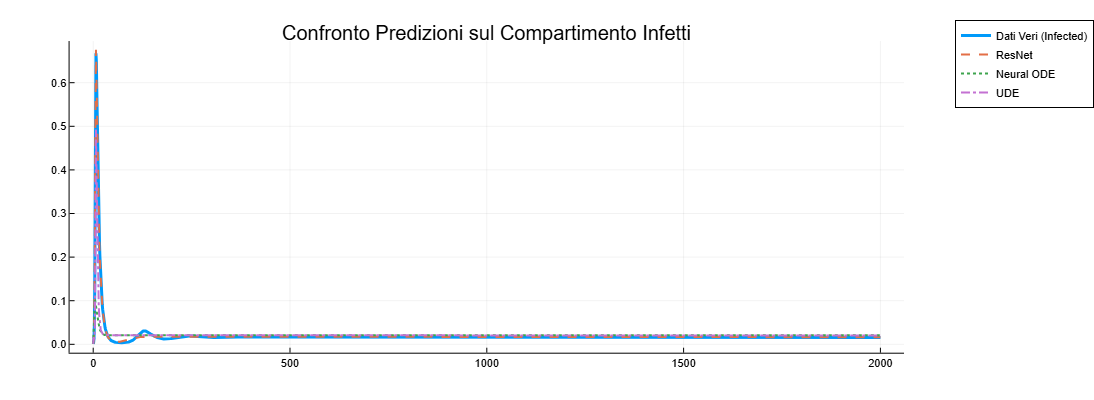

In [54]:
# Plotting results

plot(
    tsteps,
    true_traj[2, :], 
    lw=3,
    ls=:solid,
    label="Dati Veri (Infected)",
    title="Confronto Predizioni sul Compartimento Infetti",
    xlabel="Tempo (giorni)",
    ylabel="Frazione di Infetti",
    legend=:outertopright,
)

# ResNet
plot!(
     tsteps,
     pred_resnet[2, :],
     lw=2,
     ls=:dash,
     label="ResNet"
)

# Neural ODE
plot!(
    tsteps,
    pred_neural_ode[2, :],
    lw=2,
    ls=:dot,
    label="Neural ODE"
)

# UDE
plot!(
    tsteps,
    pred_ude[2, :],
    lw=2,
    ls=:dashdot,
    label="UDE"
)

current()

## 6. Noised Data

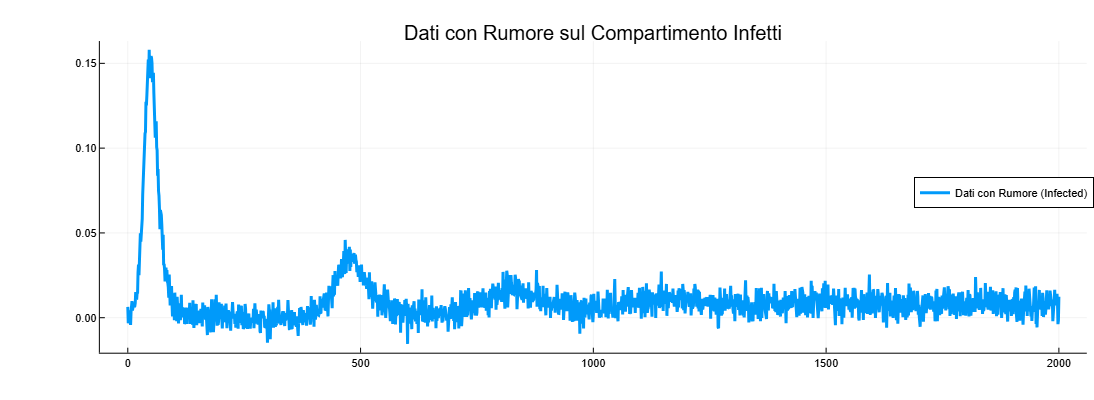

In [26]:
# Generating noised data
noised_traj = true_traj .+ 0.005f0 * randn(size(true_traj))

# plot the noised data
plot(
    tsteps,
    noised_traj[2, :],
    lw=3,
    ls=:solid,
    label="Dati con Rumore (Infected)",
    title="Dati con Rumore sul Compartimento Infetti",
    xlabel="Tempo (giorni)",
    ylabel="Frazione di Infetti",
    legend=:right,
)

In [29]:
# ResNet block
resblock = Flux.Chain(
    Flux.Dense(3, 64, relu),
    Flux.Dense(64, 64, relu),
    Flux.Dense(64, 3)
)

# Define the skip connection
resnet_model(x, m) = x .+ m(x)

# COnverting data to Float32 type so they are easier to train
X = Float32.(noised_traj[:, 1:end-1])
Y = Float32.(noised_traj[:, 2:end])

opt = ADAM(1e-2)

state = Flux.setup(opt, resblock)

# Loss function (just MSE between predicted and ground truth values)
function loss(m, x, y)
    ŷ = resnet_model(x, m)
    return Flux.Losses.mse(ŷ, y)
end

loss (generic function with 1 method)

In [30]:
# Training loop for ResNet
println("Training ResNet discreto…")
for epoch in 1:10000
    gs = gradient(resblock) do m
        loss(m, X, Y)
    end
    Flux.update!(state, resblock, gs[1])

    if epoch % 100 == 0
        @printf("  epoch %d, loss = %.8f\n", epoch, loss(resblock, X, Y))
    end
end

Training ResNet discreto…
  epoch 100, loss = 0.00004907
  epoch 200, loss = 0.00004727
  epoch 300, loss = 0.00004607
  epoch 400, loss = 0.00004537
  epoch 500, loss = 0.00004480
  epoch 600, loss = 0.00004428
  epoch 700, loss = 0.00004379
  epoch 800, loss = 0.00004333
  epoch 900, loss = 0.00004264
  epoch 1000, loss = 0.00004227
  epoch 1100, loss = 0.00004195
  epoch 1200, loss = 0.00004165
  epoch 1300, loss = 0.00004138
  epoch 1400, loss = 0.00004115
  epoch 1500, loss = 0.00004092
  epoch 1600, loss = 0.00004076
  epoch 1700, loss = 0.00004074
  epoch 1800, loss = 0.00004049
  epoch 1900, loss = 0.00004037
  epoch 2000, loss = 0.00004028
  epoch 2100, loss = 0.00004021
  epoch 2200, loss = 0.00004039
  epoch 2300, loss = 0.00004188
  epoch 2400, loss = 0.00004069
  epoch 2500, loss = 0.00003973
  epoch 2600, loss = 0.00004079
  epoch 2700, loss = 0.00004013
  epoch 2800, loss = 0.00004013
  epoch 2900, loss = 0.00003951
  epoch 3000, loss = 0.00003967
  epoch 3100, loss = 0.

In [39]:
# UDE for NOISED DATA

# Define the UDE network
ude_nn = Flux.Chain(
  Flux.Dense(3, 32, tanh),
  Flux.Dense(32, 1)
)

p_nn, st_nn = Flux.destructure(ude_nn)

# Define known parameters
γ = 1/7
μ = 1/80/365
ϑ = 1/365

p_known = Float32[γ, μ, ϑ] 
p_noise = [p_known..., p_nn...]


function ude_sirs!(du, u, p, t)
    # Divide known and unknowkn parameters
    p_known = p[1:3]
    p_nn = p[4:end]

    γ, μ, ϑ = p_known[1], p_known[2], p_known[3] # Parametri fisici
    S, I, R = u

    learned_transmission = abs(st_nn(p_nn)(u)[1])

    # Differential Equations
    du[1] = -learned_transmission + ϑ * R - μ * S   # dS/dt
    du[2] = learned_transmission - (γ+ μ) * I       # dI/dt
    du[3] = γ * I - (μ+ϑ) * R                       # dR/dt
end

# Define the ODE Problem
prob_ude = ODEProblem(
    ude_sirs!,
    u0,
    tspan,
    p_noise
)

opt = Optimisers.Adam(1e-3)
state = Optimisers.setup(opt, p_noise)

function predict_ude(p)
    return Array(solve(prob_ude,
                       Tsit5(),
                       p=p,
                       saveat=tsteps,
                       sensealg=InterpolatingAdjoint(autojacvec=ReverseDiffVJP(true))))
end

function loss_ude(p)
    pred = predict_ude(p)
    loss = sum(abs2, pred .- true_traj)
    return loss, pred
end

loss_ude (generic function with 1 method)

In [42]:
# Training loop for the UDE with noised data
opt = Optimisers.Adam(1e-3)
state = Optimisers.setup(opt, p_noise)
println("Training UDE…")
for epoch in 1:30000

    grads = gradient(p -> loss_ude(p)[1], p_noise)[1]

    state, p_noise = Optimisers.update!(state, p_noise, grads)

    if epoch % 10 == 0
        current_loss, _ = loss_ude(p_noise)
        println("Epoch $epoch | Loss = ", current_loss)
    end
end

println("Training completato.")
final_loss, final_prediction = loss_ude(p_noise)
println("Final Loss: ", final_loss)

Training UDE…
Epoch 10 | Loss = 948.9086
Epoch 20 | Loss = 957.3275
Epoch 30 | Loss = 960.6958
Epoch 40 | Loss = 961.96533
Epoch 50 | Loss = 962.3687
Epoch 60 | Loss = 962.42175
Epoch 70 | Loss = 962.3345
Epoch 80 | Loss = 962.1902
Epoch 90 | Loss = 962.0216
Epoch 100 | Loss = 961.84143
Epoch 110 | Loss = 961.6551
Epoch 120 | Loss = 961.46484
Epoch 130 | Loss = 961.27185
Epoch 140 | Loss = 961.07666
Epoch 150 | Loss = 960.8799
Epoch 160 | Loss = 960.6819
Epoch 170 | Loss = 960.48303
Epoch 180 | Loss = 960.2834
Epoch 190 | Loss = 960.0835
Epoch 200 | Loss = 959.8834
Epoch 210 | Loss = 959.68335
Epoch 220 | Loss = 959.48346
Epoch 230 | Loss = 959.28394
Epoch 240 | Loss = 959.08496
Epoch 250 | Loss = 958.8865
Epoch 260 | Loss = 958.6887
Epoch 270 | Loss = 958.49176
Epoch 280 | Loss = 958.2958
Epoch 290 | Loss = 958.1007
Epoch 300 | Loss = 957.90656
Epoch 310 | Loss = 957.7136
Epoch 320 | Loss = 957.5218
Epoch 330 | Loss = 957.3311
Epoch 340 | Loss = 957.1417
Epoch 350 | Loss = 956.9534
Ep

LoadError: InterruptException:

In [55]:
# Save the UDE parameters for noised data
# filepath = "deep_models_julia/2 Noise UDE LOSS $(round(final_loss, digits=4)) EPOCH 6000.bson"
# BSON.bson(filepath, Dict("params" => p_noise))

# println("UDE parameters saved to '$(filepath)'")

filepath = "deep_models_julia/Noise UDE LOSS 1.622 EPOCH 18000.bson"
loaded_data = BSON.load(filepath)
loaded_p_ude = loaded_data["params"]
#
pred = solve(prob_ude, Tsit5(), p=loaded_p_ude, saveat=tsteps)

retcode: Success
Interpolation: 1st order linear
t: 2001-element Vector{Float32}:
    0.0
    1.0
    2.0
    3.0
    4.0
    5.0
    6.0
    7.0
    8.0
    9.0
   10.0
   11.0
   12.0
    ⋮
 1989.0
 1990.0
 1991.0
 1992.0
 1993.0
 1994.0
 1995.0
 1996.0
 1997.0
 1998.0
 1999.0
 2000.0
u: 2001-element Vector{Vector{Float32}}:
 [0.999, 0.001, 0.0]
 [0.8084248, 0.17987284, 0.011674417]
 [0.6522939, 0.30580497, 0.041845277]
 [0.525173, 0.39004716, 0.0846962]
 [0.4221895, 0.44200972, 0.13568927]
 [0.33916155, 0.46935815, 0.19134097]
 [0.27258062, 0.47823513, 0.24901707]
 [0.21953438, 0.47350746, 0.30676314]
 [0.17761658, 0.4590039, 0.36315665]
 [0.14483495, 0.43771654, 0.41719782]
 [0.11953583, 0.41197965, 0.46820602]
 [0.10034575, 0.3835819, 0.51576596]
 [0.08611247, 0.35391092, 0.55964243]
 ⋮
 [0.13395232, 0.0154558495, 0.7966871]
 [0.13397373, 0.015453368, 0.7966418]
 [0.13399468, 0.015451482, 0.7965964]
 [0.1340153, 0.015450106, 0.7965508]
 [0.13403572, 0.015449162, 0.796505]
 [0.1340

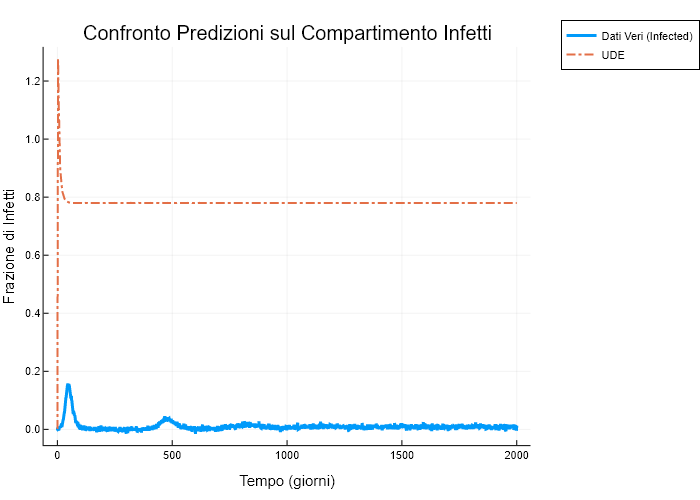

In [56]:
# plot 
pred_noise_ude = solve(prob_ude, Tsit5(), p=p_noise, saveat=tsteps)

plot(
    tsteps,
    noised_traj[2, :], 
    lw=3,
    ls=:solid,
    label="Dati Veri (Infected)",
    title="Confronto Predizioni sul Compartimento Infetti",
    xlabel="Tempo (giorni)",
    ylabel="Frazione di Infetti",
    legend=:outertopright,
)

plot!(
   plot!(
    tsteps,
    pred_noise_ude[2, :],
    lw=2,
    ls=:dashdot,
    label="UDE"
) 
)